# Notebook: Visualise subclone patterns in demo simulations of the Random Mutation Model

## Library

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob

## Function 

In [36]:
def plotting(data_plot, t, size_max, show_subclones_only=False):
    
    data_plot_t = data_plot.loc[data_plot['t(h)']==t].copy()

    if show_subclones_only:
        data_plot_t = data_plot_t.loc[data_plot_t.Has_driver_mutations=='yes'].copy()

    fig, ax = plt.subplots(ncols=1,nrows=1, figsize=(3,3))
    
    ax.scatter(
        x=data_plot_t['x(um)'].values,
        y=data_plot_t['y'].values,
        c=data_plot_t['CellColour'].values,
        s=1,
        lw=0
    )
    
    ax.set_xlim([-size_max/2, size_max/2])
    ax.set_ylim([-size_max/2, size_max/2])
    
    plt.axis('off')
    plt.show()

    plt.close()

## Settings 

In [3]:
# CHANGE THIS TO DEMO FOLDER on your device or HPC
input_directory = "./demo_on_NEMO/"

In [4]:
group_color_map = {
    'yes':'#DBA800', 'no':'grey'
}

In [25]:
conditions = ["Low Motility", "High Motility"]
subfolders = ["demo_therapy_start_at_10000cells_low_motility", "demo_therapy_start_at_10000cells_high_motility"]

# conditions = ["Low Motility"]
# subfolders = ["demo_therapy_start_at_10000cells_low_motility"]

## Read data

In [29]:
combined_data = {}
for condition, subfolder in zip(conditions, subfolders):
    path_to_nodeDynamics = glob(os.path.join(input_directory, f"{subfolder}/*nodeDynamicsTherapy.csv"))[0]
    print(condition, path_to_nodeDynamics)
    
    # read data
    data = pd.read_csv(
        path_to_nodeDynamics,
        index_col=False
    )

    # ! delete space in column name
    data.columns = [
        col.replace(' ', '')
        for col in data.columns
    ]

    # update new group ids - red, cyan, yellow
    data['Has_driver_mutations'] = data['DriverMutations'].map(
        lambda x : 'no' if x == ' ' else 'yes'
    )
    data['CellColour'] = data['Has_driver_mutations'].map(
        lambda x : group_color_map[x]
    )

    combined_data[condition] = data

Low Motility ./demo_on_NEMO/demo_therapy_start_at_10000cells_low_motility/PID_666239_seed_123_nodeDynamicsTherapy.csv
High Motility ./demo_on_NEMO/demo_therapy_start_at_10000cells_high_motility/PID_3779014_seed_123_nodeDynamicsTherapy.csv


## Visualisation 

### explore selected condition and time 

In [30]:
ts = data['t(h)'].unique() 
ts

array([  0,  24,  48,  72,  96, 120, 144, 168, 192, 216])

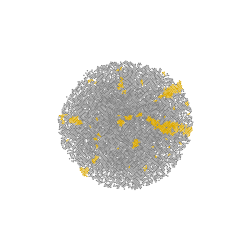

In [34]:
condition = 'Low Motility'; df = combined_data[condition]

selected_t = 168

plotting(
    data_plot=df,
    t=selected_t,
    size_max=4000,
)

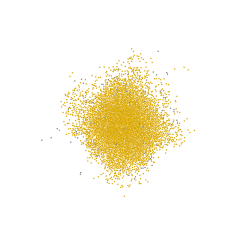

In [28]:
condition = 'High Motility'; df = combined_data[condition]

selected_t = 168

plotting(
    data_plot=df,
    t=selected_t,
    size_max=4000,
)

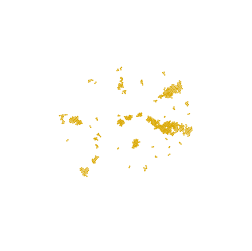

In [37]:
# one option is to only show subclones

condition = 'Low Motility'; df = combined_data[condition]

selected_t = 168

plotting(
    data_plot=df,
    t=selected_t,
    size_max=4000,
    show_subclones_only=True
)

### time series 

Note that t = 96, 120 are prior to the start of the cytotoxic therapy (when the tumour reaches 10000 cells) 

t = 120


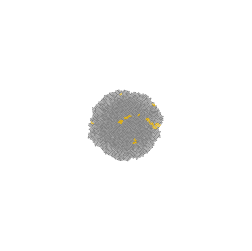

t = 144


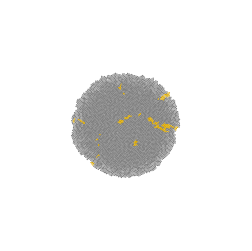

t = 168


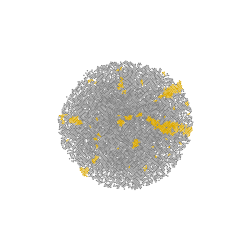

t = 192


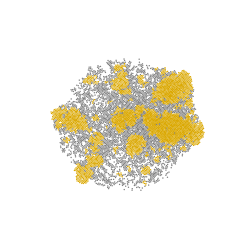

t = 216


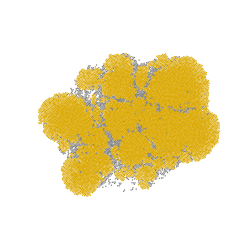

In [ ]:
condition = 'Low Motility'; df = combined_data[condition]

selected_ts = [96, 120, 144, 168, 192, 216]

for selected_t in selected_ts:
    print(f"t = {selected_t}")
    plotting(
        data_plot=df,
        t=selected_t,
        size_max=4000,
    )

t = 96


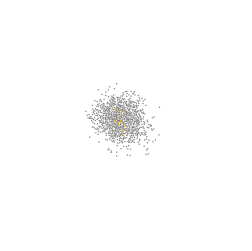

t = 120


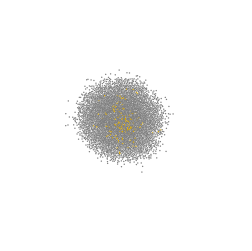

t = 144


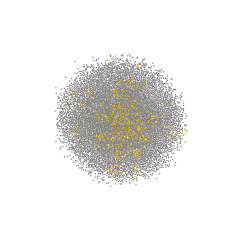

t = 168


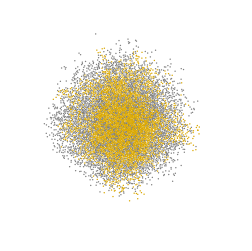

t = 192


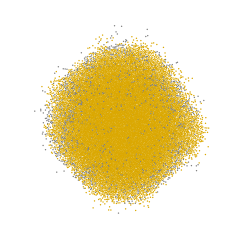

t = 216


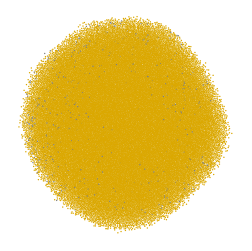

In [43]:
condition = 'High Motility'; df = combined_data[condition]

selected_ts = [96, 120, 144, 168, 192, 216]

for selected_t in selected_ts:
    print(f"t = {selected_t}")
    plotting(
        data_plot=df,
        t=selected_t,
        size_max=4000,
    )